# Notebook 02: LIME Explainability for the Fine-Tuned RoBERTa Model

## Objective

This notebook applies the Local Interpretable Model-Agnostic Explanations (LIME) framework to the fine-tuned RoBERTa classifier developed for email spam and phishing detection.

The objectives are to:

- Load the fine-tuned RoBERTa model.
- Generate prediction probabilities for email messages.
- Produce local explanations for representative ham and spam emails.
- Identify influential words contributing to model predictions.
- Save explanations as HTML reports, CSV feature tables, and high-resolution figures.
- Compare feature importance across representative case studies.

In [18]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch

from transformers import (
    AutoTokenizer,
    RobertaForSequenceClassification
)

from lime.lime_text import LimeTextExplainer

from IPython.display import display

In [2]:
# ==========================================================
# PROJECT CONFIGURATION
# ==========================================================

PROJECT_ROOT = Path(
    r"C:\Users\DELL\Documents\Email_Phishing_Project"
)

MODELS = PROJECT_ROOT / "models"

DATASETS = PROJECT_ROOT / "datasets"

REPORTS = PROJECT_ROOT / "reports"

FIGURES = PROJECT_ROOT / "figures"

REPORTS.mkdir(exist_ok=True)

FIGURES.mkdir(exist_ok=True)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

MODEL_NAME = "roberta-base"

print("=" * 70)

print("PROJECT CONFIGURATION")

print("=" * 70)

print(f"Project Root : {PROJECT_ROOT}")

print(f"Device       : {DEVICE}")

print(f"Model        : {MODEL_NAME}")

PROJECT CONFIGURATION
Project Root : C:\Users\DELL\Documents\Email_Phishing_Project
Device       : cpu
Model        : roberta-base


## 4. Load the Fine-Tuned RoBERTa Model

The tokenizer and fine-tuned RoBERTa classifier are loaded and prepared for inference. The model is transferred to the available computation device and switched to evaluation mode.

In [3]:
# ==========================================================
# LOAD TOKENIZER
# ==========================================================

print("=" * 70)
print("LOADING TOKENIZER")
print("=" * 70)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("✓ Tokenizer loaded.")

LOADING TOKENIZER


✓ Tokenizer loaded.


In [4]:
# ==========================================================
# LOAD FINE-TUNED MODEL
# ==========================================================

print("=" * 70)
print("LOADING FINE-TUNED MODEL")
print("=" * 70)

model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.load_state_dict(
    torch.load(
        MODELS / "best_roberta_model.pt",
        map_location=DEVICE
    )
)

model.to(DEVICE)

model.eval()

print("✓ Fine-tuned RoBERTa loaded successfully.")

LOADING FINE-TUNED MODEL


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Fine-tuned RoBERTa loaded successfully.


In [5]:
# ==========================================================
# VERIFY MODEL
# ==========================================================

print("=" * 70)
print("MODEL INFORMATION")
print("=" * 70)

print(f"Model Name : {MODEL_NAME}")

print(f"Device     : {DEVICE}")

print(f"Classes    : {model.config.num_labels}")

print(f"Training Mode : {model.training}")

MODEL INFORMATION
Model Name : roberta-base
Device     : cpu
Classes    : 2
Training Mode : False


## 10. Reusable LIME Explanation Function

A reusable function is implemented to generate LIME explanations for representative email samples. The function produces prediction summaries, feature importance tables, visualisations, and saves all outputs for subsequent analysis.

In [6]:
# ==========================================================
# REUSABLE LIME FUNCTION
# ==========================================================

def generate_lime_explanation(email_text, true_label, case_name):

    print("=" * 70)
    print(f"Generating explanation: {case_name}")
    print("=" * 70)

    explanation = explainer.explain_instance(
        text_instance=email_text,
        classifier_fn=predict_proba,
        labels=[true_label],
        num_features=10,
        num_samples=300
    )

    probabilities = predict_proba([email_text])[0]

    predicted_label = int(np.argmax(probabilities))

    class_names = {
        0: "Ham",
        1: "Spam"
    }

    print("\nPrediction Summary")
    print("-" * 40)

    print(f"True Label      : {class_names[true_label]}")
    print(f"Predicted Label : {class_names[predicted_label]}")
    print(f"Ham Probability : {probabilities[0]:.6f}")
    print(f"Spam Probability: {probabilities[1]:.6f}")

    importance_df = pd.DataFrame(
        explanation.as_list(label=true_label),
        columns=["Word", "Contribution"]
    )

    display(importance_df)

    fig = explanation.as_pyplot_figure(label=true_label)

    plt.tight_layout()

    plt.show()

    figure_file = FIGURES / f"{case_name}.png"

    fig.savefig(
        figure_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    csv_file = REPORTS / f"{case_name}.csv"

    importance_df.to_csv(
        csv_file,
        index=False
    )

    html_file = REPORTS / f"{case_name}.html"

    explanation.save_to_file(
        str(html_file)
    )

    print("\nFiles Saved")

    print(f"PNG  : {figure_file}")
    print(f"CSV  : {csv_file}")
    print(f"HTML : {html_file}")

    return explanation, importance_df

In [7]:
roberta_spam_explanation_1, roberta_spam_features_1 = generate_lime_explanation(
    spam_case_1["cleaned_email_text"],
    true_label=1,
    case_name="roberta_lime_spam_case1"
)

NameError: name 'spam_case_1' is not defined

In [7]:
# ==========================================================
# PREDICTION FUNCTION
# ==========================================================

def predict_proba(texts):

    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    encoded = {
        key: value.to(DEVICE)
        for key, value in encoded.items()
    }

    with torch.no_grad():

        outputs = model(**encoded)

        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )

    return probabilities.cpu().numpy()

In [8]:
# ==========================================================
# LOAD TEST DATASET
# ==========================================================

import pandas as pd

test_df = pd.read_csv(
    DATASETS / "processed" / "test_dataset.csv"
)

print("Dataset loaded successfully.")
print("Shape:", test_df.shape)
print("\nColumns:")
print(test_df.columns.tolist())

display(test_df.head())

Dataset loaded successfully.
Shape: (38799, 7)

Columns:
['dataset', 'subject', 'body', 'email_text', 'label', 'cleaned_email_text', 'email_length']


,dataset,subject,body,email_text,label,cleaned_email_text,email_length
0,Enron,Follow-up to Comments in enside,"Joe, thanks for the message. It has been my ex...","Follow-up to Comments in enside Joe, thanks fo...",0,"Follow-up to Comments in enside Joe, thanks fo...",1067
1,Enron,Re: Re[10]: FW: Victoria secret gift certificate,i am always good. i know the secret. but i h...,Re: Re[10]: FW: Victoria secret gift certifica...,0,Re: Re[10]: FW: Victoria secret gift certifica...,133
2,Enron,Re: def leppard,everyone wants to go,Re: def leppard everyone wants to go,0,Re: def leppard everyone wants to go,36
3,Enron,Start Date: 4/26/01; HourAhead hour: 18; <COD...,Start Date: 4/26/01; HourAhead hour: 18; No a...,Start Date: 4/26/01; HourAhead hour: 18; <COD...,0,Start Date: 4/26/01; HourAhead hour: 18; <CODE...,495
4,Enron,FW: Generator Contact List for CPUC investigat...,----- Forwarded by Richard B Sanders/HOU/ECT o...,FW: Generator Contact List for CPUC investigat...,0,FW: Generator Contact List for CPUC investigat...,1110


In [16]:
print(test_df.columns.tolist())
print(test_df.shape)

['dataset', 'subject', 'body', 'email_text', 'label', 'cleaned_email_text', 'email_length']
(38799, 7)


In [17]:
sample_email = test_df.loc[0, "cleaned_email_text"]

prediction = predict_proba([sample_email])

print("=" * 70)
print("PREDICTION TEST")
print("=" * 70)

print(prediction)

print()

print("Shape:", prediction.shape)

print(f"Ham Probability : {prediction[0][0]:.6f}")
print(f"Spam Probability: {prediction[0][1]:.6f}")

PREDICTION TEST
[[0.99751675 0.00248323]]

Shape: (1, 2)
Ham Probability : 0.997517
Spam Probability: 0.002483


In [9]:
# ==========================================================
# LOAD TEST DATASET
# ==========================================================

import pandas as pd

test_df = pd.read_csv(
    DATASETS / "processed" / "test_dataset.csv"
)

print("Dataset loaded successfully.")
print("Shape:", test_df.shape)
print("\nColumns:")
print(test_df.columns.tolist())

display(test_df.head())

Dataset loaded successfully.
Shape: (38799, 7)

Columns:
['dataset', 'subject', 'body', 'email_text', 'label', 'cleaned_email_text', 'email_length']


,dataset,subject,body,email_text,label,cleaned_email_text,email_length
0,Enron,Follow-up to Comments in enside,"Joe, thanks for the message. It has been my ex...","Follow-up to Comments in enside Joe, thanks fo...",0,"Follow-up to Comments in enside Joe, thanks fo...",1067
1,Enron,Re: Re[10]: FW: Victoria secret gift certificate,i am always good. i know the secret. but i h...,Re: Re[10]: FW: Victoria secret gift certifica...,0,Re: Re[10]: FW: Victoria secret gift certifica...,133
2,Enron,Re: def leppard,everyone wants to go,Re: def leppard everyone wants to go,0,Re: def leppard everyone wants to go,36
3,Enron,Start Date: 4/26/01; HourAhead hour: 18; <COD...,Start Date: 4/26/01; HourAhead hour: 18; No a...,Start Date: 4/26/01; HourAhead hour: 18; <COD...,0,Start Date: 4/26/01; HourAhead hour: 18; <CODE...,495
4,Enron,FW: Generator Contact List for CPUC investigat...,----- Forwarded by Richard B Sanders/HOU/ECT o...,FW: Generator Contact List for CPUC investigat...,0,FW: Generator Contact List for CPUC investigat...,1110


In [12]:
test_df = pd.read_csv(
    DATASETS / "processed" / "bert_test_subset.csv"
)

print(test_df.shape)

(1000, 7)


In [13]:
# ==========================================================
# GENERATE PREDICTIONS ON EVALUATION SUBSET
# ==========================================================

from tqdm.auto import tqdm

predicted_labels = []
ham_probabilities = []
spam_probabilities = []

# Optimized for CPU inference
batch_size = 128

print("=" * 70)
print("GENERATING PREDICTIONS ON EVALUATION SUBSET")
print("=" * 70)

for start in tqdm(
    range(0, len(test_df), batch_size),
    desc="RoBERTa Inference"
):

    end = min(start + batch_size, len(test_df))

    batch = (
        test_df["cleaned_email_text"]
        .fillna("")
        .iloc[start:end]
        .tolist()
    )

    probabilities = predict_proba(batch)

    predicted_labels.extend(
        np.argmax(probabilities, axis=1)
    )

    ham_probabilities.extend(probabilities[:, 0])

    spam_probabilities.extend(probabilities[:, 1])

# Store predictions
test_df["predicted_label"] = predicted_labels
test_df["ham_probability"] = ham_probabilities
test_df["spam_probability"] = spam_probabilities
test_df["correct_prediction"] = (
    test_df["label"] == test_df["predicted_label"]
)

accuracy = test_df["correct_prediction"].mean()

print("\n" + "=" * 70)
print("PREDICTION SUMMARY")
print("=" * 70)

print(f"Evaluation Samples : {len(test_df)}")
print(f"Correct Predictions: {test_df['correct_prediction'].sum()}")
print(f"Accuracy           : {accuracy:.4f}")

GENERATING PREDICTIONS ON EVALUATION SUBSET


RoBERTa Inference:   0%|          | 0/8 [00:00<?, ?it/s]


PREDICTION SUMMARY
Evaluation Samples : 1000
Correct Predictions: 993
Accuracy           : 0.9930


In [14]:
correct_predictions = test_df[
    test_df["correct_prediction"]
].copy()

correct_spam = (
    correct_predictions[
        correct_predictions["label"] == 1
    ]
    .sort_values("spam_probability", ascending=False)
    .reset_index(drop=True)
)

correct_ham = (
    correct_predictions[
        correct_predictions["label"] == 0
    ]
    .sort_values("ham_probability", ascending=False)
    .reset_index(drop=True)
)

spam_case_1 = correct_spam.iloc[0]
spam_case_2 = correct_spam.iloc[1]

ham_case_1 = correct_ham.iloc[0]
ham_case_2 = correct_ham.iloc[1]

print("=" * 70)
print("REPRESENTATIVE EMAILS SELECTED")
print("=" * 70)

print(f"Correct Spam Emails : {len(correct_spam)}")
print(f"Correct Ham Emails  : {len(correct_ham)}")

print("\n✓ Spam Case 1")
print(f"Spam Probability : {spam_case_1['spam_probability']:.6f}")

print("\n✓ Spam Case 2")
print(f"Spam Probability : {spam_case_2['spam_probability']:.6f}")

print("\n✓ Ham Case 1")
print(f"Ham Probability : {ham_case_1['ham_probability']:.6f}")

print("\n✓ Ham Case 2")
print(f"Ham Probability : {ham_case_2['ham_probability']:.6f}")

REPRESENTATIVE EMAILS SELECTED
Correct Spam Emails : 86
Correct Ham Emails  : 907

✓ Spam Case 1
Spam Probability : 0.998103

✓ Spam Case 2
Spam Probability : 0.998069

✓ Ham Case 1
Ham Probability : 0.997829

✓ Ham Case 2
Ham Probability : 0.997788


In [19]:
roberta_spam_explanation_1, roberta_spam_features_1 = generate_lime_explanation(
    spam_case_1["cleaned_email_text"],
    true_label=1,
    case_name="roberta_lime_spam_case1"
)

Generating explanation: roberta_lime_spam_case1


NameError: name 'explainer' is not defined

In [21]:
import lime

print(lime.__version__)

AttributeError: module 'lime' has no attribute '__version__'

In [22]:
from lime.lime_text import LimeTextExplainer

In [23]:
# ==========================================================
# INITIALIZE LIME EXPLAINER
# ==========================================================

print("=" * 70)
print("INITIALIZING LIME EXPLAINER")
print("=" * 70)

explainer = LimeTextExplainer(
    class_names=["Ham", "Spam"],
    random_state=42
)

print("✓ LIME explainer initialized successfully.")

INITIALIZING LIME EXPLAINER
✓ LIME explainer initialized successfully.


In [24]:
print(type(explainer))

<class 'lime.lime_text.LimeTextExplainer'>


Generating explanation: roberta_lime_spam_case1

Prediction Summary
----------------------------------------
True Label      : Spam
Predicted Label : Spam
Ham Probability : 0.001897
Spam Probability: 0.998103


,Word,Contribution
0,male,0.011994
1,d524b4d0b56ddb737de5a8004f36a63d,0.010791
2,personal,0.010001
3,you,0.009679
4,him,0.009201
5,can,0.009130
6,best,0.008082
7,11,-0.007867
8,enhancing,-0.005760
9,proposal,-0.005214


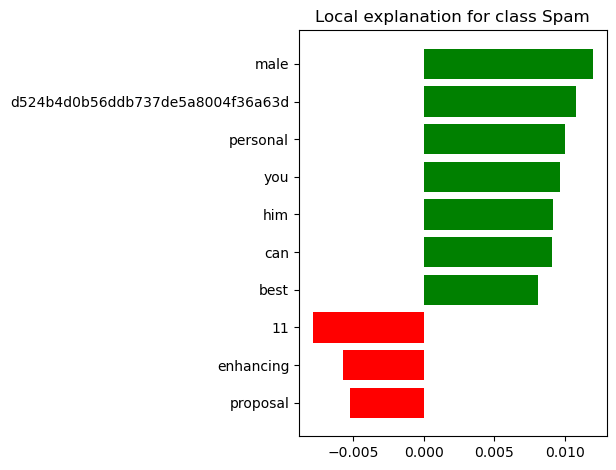


Files Saved
PNG  : C:\Users\DELL\Documents\Email_Phishing_Project\figures\roberta_lime_spam_case1.png
CSV  : C:\Users\DELL\Documents\Email_Phishing_Project\reports\roberta_lime_spam_case1.csv
HTML : C:\Users\DELL\Documents\Email_Phishing_Project\reports\roberta_lime_spam_case1.html


In [25]:
roberta_spam_explanation_1, roberta_spam_features_1 = generate_lime_explanation(
    spam_case_1["cleaned_email_text"],
    true_label=1,
    case_name="roberta_lime_spam_case1"
)

Generating explanation: roberta_lime_spam_case2

Prediction Summary
----------------------------------------
True Label      : Spam
Predicted Label : Spam
Ham Probability : 0.001931
Spam Probability: 0.998069


,Word,Contribution
0,for,0.011208
1,only,0.011205
2,perfect,0.010893
3,Discounts,0.010201
4,pharmacy,0.008730
5,woman,0.007953
6,Want,0.007864
7,problems,-0.007396
8,MORE,0.007255
9,ON,-0.006129


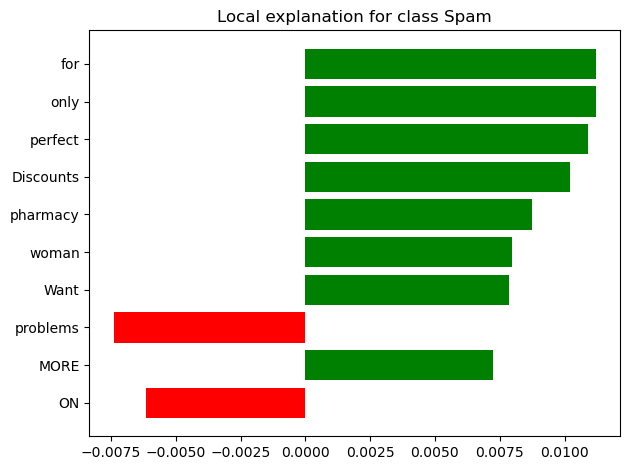


Files Saved
PNG  : C:\Users\DELL\Documents\Email_Phishing_Project\figures\roberta_lime_spam_case2.png
CSV  : C:\Users\DELL\Documents\Email_Phishing_Project\reports\roberta_lime_spam_case2.csv
HTML : C:\Users\DELL\Documents\Email_Phishing_Project\reports\roberta_lime_spam_case2.html


In [26]:
roberta_spam_explanation_2, roberta_spam_features_2 = generate_lime_explanation(
    spam_case_2["cleaned_email_text"],
    true_label=1,
    case_name="roberta_lime_spam_case2"
)

Generating explanation: roberta_lime_ham_case1

Prediction Summary
----------------------------------------
True Label      : Ham
Predicted Label : Ham
Ham Probability : 0.997829
Spam Probability: 0.002171


,Word,Contribution
0,2000,0.004200
1,Lee,0.004131
2,monetization,0.003833
3,Re,0.003378
4,perspective,0.002896
5,take,0.002048
6,Met,0.001980
7,s,-0.000962
8,is,-0.000375
9,Monday,-0.000352


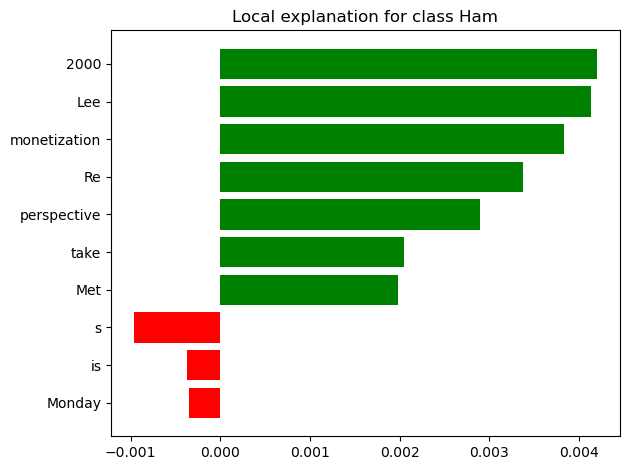


Files Saved
PNG  : C:\Users\DELL\Documents\Email_Phishing_Project\figures\roberta_lime_ham_case1.png
CSV  : C:\Users\DELL\Documents\Email_Phishing_Project\reports\roberta_lime_ham_case1.csv
HTML : C:\Users\DELL\Documents\Email_Phishing_Project\reports\roberta_lime_ham_case1.html


In [27]:
roberta_ham_explanation_1, roberta_ham_features_1 = generate_lime_explanation(
    ham_case_1["cleaned_email_text"],
    true_label=0,
    case_name="roberta_lime_ham_case1"
)

Generating explanation: roberta_lime_ham_case2

Prediction Summary
----------------------------------------
True Label      : Ham
Predicted Label : Ham
Ham Probability : 0.997788
Spam Probability: 0.002212


,Word,Contribution
0,Rob,0.001357
1,Subject,0.001216
2,everyone,0.001042
3,Kari,0.001020
4,home,0.000588
5,chance,0.000500
6,make,0.000330
7,Sunday,0.000316
8,visit,-0.000134
9,horse,0.000089


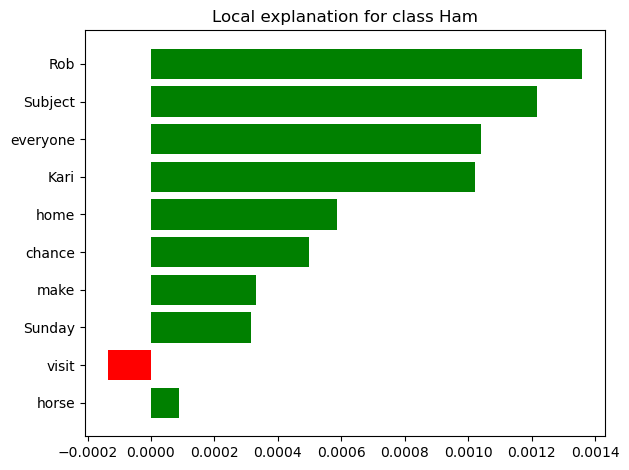


Files Saved
PNG  : C:\Users\DELL\Documents\Email_Phishing_Project\figures\roberta_lime_ham_case2.png
CSV  : C:\Users\DELL\Documents\Email_Phishing_Project\reports\roberta_lime_ham_case2.csv
HTML : C:\Users\DELL\Documents\Email_Phishing_Project\reports\roberta_lime_ham_case2.html


In [28]:
roberta_ham_explanation_2, roberta_ham_features_2 = generate_lime_explanation(
    ham_case_2["cleaned_email_text"],
    true_label=0,
    case_name="roberta_lime_ham_case2"
)

In [29]:
# ==========================================================
# SUMMARY OF ROBERTA LIME EXPLANATIONS
# ==========================================================

summary = pd.DataFrame({
    "Case": [
        "Spam Case 1",
        "Spam Case 2",
        "Ham Case 1",
        "Ham Case 2"
    ],
    "True Label": [
        "Spam",
        "Spam",
        "Ham",
        "Ham"
    ],
    "Predicted Label": [
        "Spam",
        "Spam",
        "Ham",
        "Ham"
    ],
    "Confidence": [
        spam_case_1["spam_probability"],
        spam_case_2["spam_probability"],
        ham_case_1["ham_probability"],
        ham_case_2["ham_probability"]
    ]
})

summary = summary.round(6)

display(summary)

summary.to_csv(
    REPORTS / "roberta_lime_summary.csv",
    index=False
)

print("\n✓ Summary saved successfully.")

,Case,True Label,Predicted Label,Confidence
0,Spam Case 1,Spam,Spam,0.998103
1,Spam Case 2,Spam,Spam,0.998069
2,Ham Case 1,Ham,Ham,0.997829
3,Ham Case 2,Ham,Ham,0.997788



✓ Summary saved successfully.
